# Online Retail II — RFM Segmentation

This notebook builds customer-level RFM features and segments customers based on recency, frequency, and monetary value.

The input is the cleaned customer analytics dataset created in `02_cleaning.ipynb`.

In [1]:
# Section 1 — Setup and load

from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve project root by walking up until the data/ directory is found.
def find_project_root(marker: str = "data") -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root; no '{marker}/' directory found."
    )


project_root = find_project_root()
cleaned_path = project_root / "data" / "processed" / "online_retail_cleaned.parquet"
assert cleaned_path.exists(), f"Cleaned file not found: {cleaned_path}"
cleaned = pd.read_parquet(cleaned_path)

# Validate Stage 2 contract: shape.
expected_shape = (776_579, 9)
assert cleaned.shape == expected_shape, (
    f"Expected {expected_shape}, got {cleaned.shape}. "
    "Stage 2 output may have changed; re-check before proceeding."
)

# Validate Stage 2 contract: column set and order.
expected_columns = [
    "Invoice", "StockCode", "Description", "Quantity",
    "InvoiceDate", "Price", "Customer ID", "Country", "Revenue",
]
assert list(cleaned.columns) == expected_columns, (
    f"Column mismatch. Got {list(cleaned.columns)}"
)

# Validate Stage 2 contract: dtype predicates.
assert pd.api.types.is_string_dtype(cleaned["Invoice"]), (
    "Invoice should be string-like."
)
assert pd.api.types.is_string_dtype(cleaned["StockCode"]), (
    "StockCode should be string-like."
)
assert pd.api.types.is_integer_dtype(cleaned["Quantity"]), (
    "Quantity should be integer."
)
assert pd.api.types.is_datetime64_any_dtype(cleaned["InvoiceDate"]), (
    "InvoiceDate should be datetime."
)
assert pd.api.types.is_numeric_dtype(cleaned["Price"]), (
    "Price should be numeric."
)
assert str(cleaned["Customer ID"].dtype) == "Int64", (
    f"Customer ID must be nullable Int64, got {cleaned['Customer ID'].dtype}."
)
assert pd.api.types.is_numeric_dtype(cleaned["Revenue"]), (
    "Revenue should be numeric."
)

# Validate Stage 2 contract: required fields for RFM.
required_columns = [
    "Invoice", "InvoiceDate", "Customer ID",
    "Quantity", "Price", "Revenue",
]
for required_column in required_columns:
    null_count = cleaned[required_column].isna().sum()
    assert null_count == 0, f"{required_column} contains {null_count} nulls."

# Validate Stage 2 contract: positive numeric fields.
assert (cleaned["Quantity"] > 0).all(), (
    "Quantity contains non-positive values."
)
assert (cleaned["Price"] > 0).all(), (
    "Price contains non-positive values."
)
assert (cleaned["Revenue"] > 0).all(), (
    "Revenue contains non-positive values."
)

# Validate Stage 2 contract: standard invoice format.
invoice_format_valid = cleaned["Invoice"].str.fullmatch(r"\d{6}", na=False)
assert invoice_format_valid.all(), (
    f"{(~invoice_format_valid).sum()} invoices do not match 6-digit format."
)

# Report load summary.
print(f"Loaded: {cleaned.shape[0]:,} rows × {cleaned.shape[1]} columns")
print(f"Project root: {project_root}")
print(f"Unique customers: {cleaned['Customer ID'].nunique():,}")
print(f"Unique invoices: {cleaned['Invoice'].nunique():,}")
print(f"Date range: {cleaned['InvoiceDate'].min()} to {cleaned['InvoiceDate'].max()}")
print(f"Total revenue: {cleaned['Revenue'].sum():,.2f}")

Loaded: 776,579 rows × 9 columns
Project root: C:\Users\Lenovo\Desktop\projects\retail-analytics
Unique customers: 5,852
Unique invoices: 36,594
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total revenue: 17,068,582.72


In [2]:
# Section 2 — Snapshot date and RFM aggregation

# Define snapshot date as one day after the last invoice in the dataset.
# This keeps the most recent purchasers at Recency = 1 instead of 0.
snapshot_date = cleaned["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Snapshot date: {snapshot_date}")

# Aggregate to one row per customer.
rfm = (
    cleaned.groupby("Customer ID")
    .agg(
        last_invoice_date=("InvoiceDate", "max"),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

# Calculate recency as whole days since each customer's last purchase.
rfm["Recency"] = (snapshot_date - rfm["last_invoice_date"]).dt.days
rfm = rfm.drop(columns="last_invoice_date")

# Reorder columns for readability.
rfm = rfm[["Customer ID", "Recency", "Frequency", "Monetary"]]

# Validate RFM contract: one row per customer.
expected_customer_count = 5_852
assert rfm.shape == (expected_customer_count, 4), (
    f"Expected ({expected_customer_count}, 4), got {rfm.shape}."
)
assert rfm.shape[0] == cleaned["Customer ID"].nunique(), (
    "RFM row count does not match unique customer count."
)

# Validate RFM contract: no nulls.
rfm_columns = ["Customer ID", "Recency", "Frequency", "Monetary"]

for rfm_column in rfm_columns:
    null_count = rfm[rfm_column].isna().sum()
    assert null_count == 0, f"{rfm_column} contains {null_count} nulls."

# Validate RFM contract: positive ranges.
assert (rfm["Recency"] >= 1).all(), "Recency contains values below 1."
assert (rfm["Frequency"] >= 1).all(), "Frequency contains values below 1."
assert (rfm["Monetary"] > 0).all(), "Monetary contains non-positive values."

# Validate that customer-level Monetary reconciles to total cleaned revenue.
monetary_total = rfm["Monetary"].sum()
revenue_total = cleaned["Revenue"].sum()

assert math.isclose(monetary_total, revenue_total, rel_tol=1e-9), (
    f"Monetary sum {monetary_total:,.2f} does not match "
    f"cleaned revenue total {revenue_total:,.2f}."
)

# Report RFM build summary.
print(f"RFM rows: {rfm.shape[0]:,}  (one per customer)")
print(f"Recency range: {rfm['Recency'].min()} to {rfm['Recency'].max()} days")
print(f"Frequency range: {rfm['Frequency'].min()} to {rfm['Frequency'].max()} invoices")
print(f"Monetary range: {rfm['Monetary'].min():,.2f} to {rfm['Monetary'].max():,.2f}")
print(f"Monetary sum: {monetary_total:,.2f}  (matches cleaned revenue total)")

print()
print(rfm.head())

print()
print(rfm.dtypes)

Snapshot date: 2011-12-10 12:50:00
RFM rows: 5,852  (one per customer)
Recency range: 1 to 739 days
Frequency range: 1 to 373 invoices
Monetary range: 2.95 to 580,987.04
Monetary sum: 17,068,582.72  (matches cleaned revenue total)

   Customer ID  Recency  Frequency  Monetary
0        12346      326          3  77352.96
1        12347        2          8   4921.53
2        12348       75          5   1658.40
3        12349       19          3   3678.69
4        12350      310          1    294.40

Customer ID      Int64
Recency          int64
Frequency        int64
Monetary       float64
dtype: object


Numeric profile:
       Recency  Frequency   Monetary
count  5852.00    5852.00    5852.00
mean    200.20       6.25    2916.71
std     208.51      12.75   14306.87
min       1.00       1.00       2.95
5%        4.00       1.00     112.54
25%      25.00       1.00     339.58
50%      95.00       3.00     856.02
75%     379.00       7.00    2241.03
90%     531.00      13.00    5392.77
95%     623.45      20.00    9270.27
99%     726.00      46.00   28631.08
max     739.00     373.00  580987.04
skew      0.89      12.04      25.33

Frequency concentration (lowest 10 values):
           customer_count  customer_percent  cumulative_percent
Frequency                                                      
1                    1618             27.65               27.65
2                     945             16.15               43.80
3                     659             11.26               55.06
4                     489              8.36               63.41
5                     355           

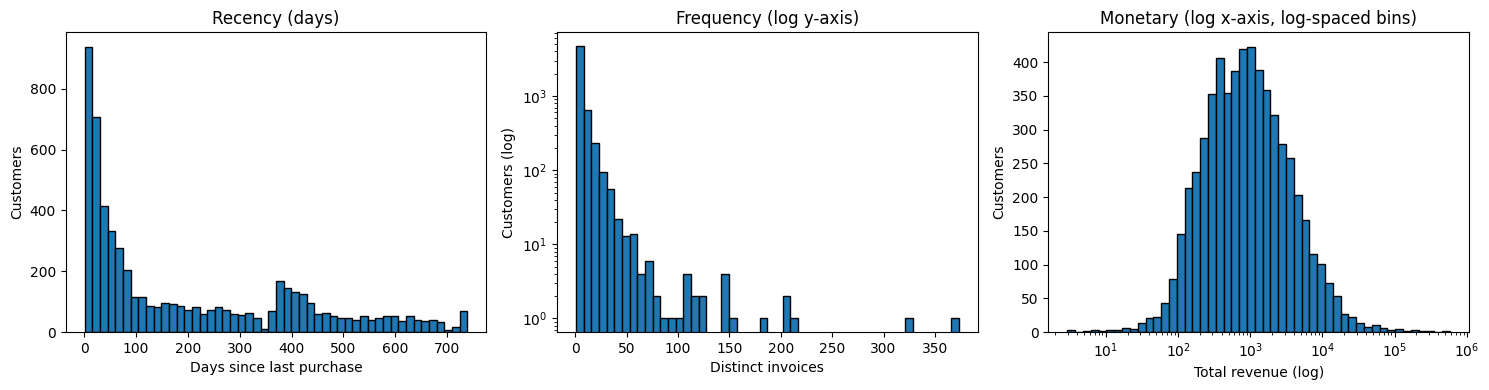

In [3]:
# Section 3 — Distribution profiling

# 3a — Numeric profile with extended percentiles and skewness.
percentiles_of_interest = [0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
numeric_profile = rfm[["Recency", "Frequency", "Monetary"]].describe(
    percentiles=percentiles_of_interest
)
numeric_profile.loc["skew"] = rfm[["Recency", "Frequency", "Monetary"]].skew()
print("Numeric profile:")
print(numeric_profile.round(2))
print()

# 3b — Frequency concentration at low purchase counts.
frequency_concentration = (
    rfm["Frequency"]
    .value_counts()
    .sort_index()
    .head(10)
    .to_frame(name="customer_count")
)
frequency_concentration["customer_percent"] = (
    frequency_concentration["customer_count"] / len(rfm) * 100
).round(2)
frequency_concentration["cumulative_percent"] = (
    frequency_concentration["customer_count"].cumsum() / len(rfm) * 100
).round(2)
print("Frequency concentration (lowest 10 values):")
print(frequency_concentration)
print()

# 3c — Revenue concentration among top-spending customers.
monetary_sorted = rfm["Monetary"].sort_values(ascending=False).reset_index(drop=True)
total_revenue = monetary_sorted.sum()
top_percentages = [1, 5, 10, 20]
print("Monetary tail concentration:")
for top_percent in top_percentages:
    customer_cutoff = math.ceil(len(monetary_sorted) * top_percent / 100)
    revenue_share = monetary_sorted.iloc[:customer_cutoff].sum() / total_revenue * 100
    print(
        f"  Top {top_percent:>2}% of customers ({customer_cutoff:>4} customers): "
        f"{revenue_share:5.2f}% of revenue"
    )
print()

# 3d — Distribution plots for each RFM dimension.
figure, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["Recency"], bins=50, edgecolor="black")
axes[0].set_title("Recency (days)")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Customers")

axes[1].hist(rfm["Frequency"], bins=50, edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_title("Frequency (log y-axis)")
axes[1].set_xlabel("Distinct invoices")
axes[1].set_ylabel("Customers (log)")

monetary_log_bins = np.logspace(
    np.log10(rfm["Monetary"].min()),
    np.log10(rfm["Monetary"].max()),
    50,
)
axes[2].hist(rfm["Monetary"], bins=monetary_log_bins, edgecolor="black")
axes[2].set_xscale("log")
axes[2].set_title("Monetary (log x-axis, log-spaced bins)")
axes[2].set_xlabel("Total revenue (log)")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [4]:
# Section 4 — RFM scoring

# 4a — Recency scoring via quintiles. Lower Recency means a better customer.
recency_codes, recency_edges = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=False,
    duplicates="drop",
    retbins=True,
)

n_bins_recency = recency_codes.nunique()
assert n_bins_recency == 5, (
    f"Recency must produce exactly 5 bins for valid scoring; got {n_bins_recency}."
)

rfm["R_Score"] = (n_bins_recency - recency_codes).astype("int8")

# 4b — Frequency scoring via fixed cutoffs derived from Section 3 percentiles.
# Quintile binning fails because F = 1 holds 27.65% of customers.
frequency_bin_edges = [0, 1, 3, 6, 12, float("inf")]
frequency_score_labels = [1, 2, 3, 4, 5]

rfm["F_Score"] = pd.cut(
    rfm["Frequency"],
    bins=frequency_bin_edges,
    labels=frequency_score_labels,
).astype("int8")

# 4c — Monetary scoring via quintiles. Higher Monetary means a better customer.
monetary_codes, monetary_edges = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=False,
    duplicates="drop",
    retbins=True,
)

n_bins_monetary = monetary_codes.nunique()
assert n_bins_monetary == 5, (
    f"Monetary must produce exactly 5 bins for valid scoring; got {n_bins_monetary}."
)

rfm["M_Score"] = (monetary_codes + 1).astype("int8")

# 4d — Combined RFM_Score as a 3-character string for downstream output.
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

# Validate score contracts.
score_columns = ["R_Score", "F_Score", "M_Score"]

for score_column in score_columns:
    assert rfm[score_column].notna().all(), f"{score_column} contains nulls."
    assert rfm[score_column].between(1, 5).all(), (
        f"{score_column} contains values outside [1, 5]."
    )

assert rfm["RFM_Score"].notna().all(), "RFM_Score contains nulls."
assert rfm["RFM_Score"].str.fullmatch(r"[1-5]{3}").all(), (
    "RFM_Score contains values outside the [1-5][1-5][1-5] pattern."
)

# Report Recency scoring diagnostics.
print(f"Recency bin edges (n_bins = {n_bins_recency}):")
print(f"  {[round(edge, 2) for edge in recency_edges]}")
print()

print("Customers per R_Score:")
print(rfm["R_Score"].value_counts().sort_index())
print()

# Report Frequency scoring diagnostics.
print("Frequency scoring cutoffs:")
print("  1 invoice      -> F_Score 1")
print("  2-3 invoices   -> F_Score 2")
print("  4-6 invoices   -> F_Score 3")
print("  7-12 invoices  -> F_Score 4")
print("  13+ invoices   -> F_Score 5")
print()

print("Customers per F_Score:")
print(rfm["F_Score"].value_counts().sort_index())
print()

# Report Monetary scoring diagnostics.
print(f"Monetary bin edges (n_bins = {n_bins_monetary}):")
print(f"  {[round(edge, 2) for edge in monetary_edges]}")
print()

print("Customers per M_Score:")
print(rfm["M_Score"].value_counts().sort_index())
print()

# Sample of scored customers.
print(rfm.head())
print()
print(rfm.dtypes)

Recency bin edges (n_bins = 5):
  [np.float64(1.0), np.float64(19.0), np.float64(59.0), np.float64(187.0), np.float64(409.0), np.float64(739.0)]

Customers per R_Score:
R_Score
1    1163
2    1173
3    1155
4    1174
5    1187
Name: count, dtype: int64

Frequency scoring cutoffs:
  1 invoice      -> F_Score 1
  2-3 invoices   -> F_Score 2
  4-6 invoices   -> F_Score 3
  7-12 invoices  -> F_Score 4
  13+ invoices   -> F_Score 5

Customers per F_Score:
F_Score
1    1618
2    1604
3    1122
4     864
5     644
Name: count, dtype: int64

Monetary bin edges (n_bins = 5):
  [np.float64(2.95), np.float64(285.35), np.float64(603.44), np.float64(1207.31), np.float64(2887.41), np.float64(580987.04)]

Customers per M_Score:
M_Score
1    1171
2    1170
3    1170
4    1170
5    1171
Name: count, dtype: int64

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326          3  77352.96        2        2        5   
1        12347        2          8   4921.

In [5]:
# Section 5 — Segment assignment

# Initialise segment column. Customers without a rule match remain NaN
# until the residual catch-all rule assigns them.
rfm["Segment"] = pd.NA


# Apply a rule only to customers not yet assigned.
def assign_segment(mask: pd.Series, segment_name: str) -> None:
    eligible = mask & rfm["Segment"].isna()
    rfm.loc[eligible, "Segment"] = segment_name


# Apply rules in agreed precedence order.
assign_segment(
    rfm["R_Score"].isin([4, 5]) & rfm["F_Score"].isin([4, 5]),
    "Champions",
)
assign_segment(
    (rfm["R_Score"] == 1) & rfm["F_Score"].isin([4, 5]),
    "Can't Lose Them",
)
assign_segment(
    rfm["R_Score"].isin([3, 4, 5]) & rfm["F_Score"].isin([4, 5]),
    "Loyal Customers",
)
assign_segment(
    rfm["R_Score"].isin([4, 5]) & rfm["F_Score"].isin([2, 3]),
    "Potential Loyalists",
)
assign_segment(
    (rfm["R_Score"] == 5) & (rfm["F_Score"] == 1),
    "New Customers",
)
assign_segment(
    (rfm["R_Score"] == 4) & (rfm["F_Score"] == 1),
    "Promising",
)
assign_segment(
    (rfm["R_Score"] == 3) & rfm["F_Score"].isin([2, 3]),
    "Need Attention",
)
assign_segment(
    (rfm["R_Score"] == 3) & (rfm["F_Score"] == 1),
    "About to Sleep",
)
assign_segment(
    rfm["R_Score"].isin([1, 2]) & rfm["F_Score"].isin([3, 4, 5]),
    "At Risk",
)
assign_segment(
    (rfm["R_Score"] == 1) & (rfm["F_Score"] == 1),
    "Lost",
)
# Residual catch-all: all remaining customers.
rfm.loc[rfm["Segment"].isna(), "Segment"] = "Hibernating"

# Cast Segment to pandas string dtype for downstream output.
rfm["Segment"] = rfm["Segment"].astype("string")

# Validate segment contract.
assert rfm["Segment"].notna().all(), (
    f"{rfm['Segment'].isna().sum()} customers were not assigned a segment."
)
expected_segments = {
    "Champions", "Can't Lose Them", "Loyal Customers", "Potential Loyalists",
    "New Customers", "Promising", "Need Attention", "About to Sleep",
    "At Risk", "Lost", "Hibernating",
}
unexpected_segments = set(rfm["Segment"].unique()) - expected_segments
assert not unexpected_segments, (
    f"Unexpected segment labels found: {unexpected_segments}"
)

# Diagnostic: report any rules that did not fire on this dataset.
missing_segments = expected_segments - set(rfm["Segment"].unique())
if missing_segments:
    print(f"Note: segments with zero customers: {sorted(missing_segments)}")
    print()

# Report segment distribution.
segment_distribution = (
    rfm["Segment"]
    .value_counts()
    .to_frame(name="customer_count")
)
segment_distribution["customer_percent"] = (
    segment_distribution["customer_count"] / len(rfm) * 100
).round(2)
print("Segment distribution:")
print(segment_distribution)
print()

# Confirm segment counts reconcile to the customer count.
assert segment_distribution["customer_count"].sum() == len(rfm), (
    "Segment counts do not sum to total customer count."
)
print(
    "Total customers across all segments: "
    f"{segment_distribution['customer_count'].sum():,}"
)

# Sample of segmented customers.
print()
print(rfm.head())
print()
print(rfm.dtypes)

Segment distribution:
                     customer_count  customer_percent
Segment                                              
Hibernating                    1170             19.99
Champions                      1091             18.64
Potential Loyalists            1028             17.57
Lost                            710             12.13
Need Attention                  627             10.71
At Risk                         423              7.23
Loyal Customers                 283              4.84
About to Sleep                  245              4.19
Promising                       166              2.84
New Customers                    76               1.3
Can't Lose Them                  33              0.56

Total customers across all segments: 5,852

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326          3  77352.96        2        2        5   
1        12347        2          8   4921.53        5        4        5   
2     

In [6]:
# Section 6 — Segment profiling

# Build per-segment summary using a single named aggregation pass.
segment_profile = (
    rfm.groupby("Segment")
    .agg(
        customer_count=("Customer ID", "count"),
        mean_recency=("Recency", "mean"),
        mean_frequency=("Frequency", "mean"),
        mean_monetary=("Monetary", "mean"),
        total_revenue=("Monetary", "sum"),
    )
)

# Add percentage columns derived from the totals.
total_customers = len(rfm)
total_revenue = rfm["Monetary"].sum()
segment_profile["customer_percent"] = (
    segment_profile["customer_count"] / total_customers * 100
)
segment_profile["revenue_percent"] = (
    segment_profile["total_revenue"] / total_revenue * 100
)

# Reorder columns for analytical readability.
segment_profile = segment_profile[[
    "customer_count", "customer_percent",
    "mean_recency", "mean_frequency", "mean_monetary",
    "total_revenue", "revenue_percent",
]]

# Sort by revenue contribution descending so the analytical priority leads.
segment_profile = segment_profile.sort_values(
    by="revenue_percent", ascending=False
)

# Round display values without losing underlying precision.
segment_profile_display = segment_profile.copy()
segment_profile_display["customer_percent"] = (
    segment_profile_display["customer_percent"].round(2)
)
segment_profile_display["mean_recency"] = (
    segment_profile_display["mean_recency"].round(0).astype(int)
)
segment_profile_display["mean_frequency"] = (
    segment_profile_display["mean_frequency"].round(2)
)
segment_profile_display["mean_monetary"] = (
    segment_profile_display["mean_monetary"].round(2)
)
segment_profile_display["total_revenue"] = (
    segment_profile_display["total_revenue"].round(2)
)
segment_profile_display["revenue_percent"] = (
    segment_profile_display["revenue_percent"].round(2)
)

# Validate reconciliation: customer counts and revenue totals.
assert segment_profile["customer_count"].sum() == total_customers, (
    "Segment customer counts do not sum to total customers."
)
assert math.isclose(
    segment_profile["total_revenue"].sum(), total_revenue, rel_tol=1e-9
), "Segment total_revenue does not reconcile to overall revenue."
assert math.isclose(
    segment_profile["customer_percent"].sum(), 100.0, abs_tol=1e-6
), "Segment customer percentages do not sum to 100."
assert math.isclose(
    segment_profile["revenue_percent"].sum(), 100.0, abs_tol=1e-6
), "Segment revenue percentages do not sum to 100."

# Report the profile.
print("Segment profile (sorted by revenue contribution):")
print(segment_profile_display)
print()
print(
    f"Reconciliation: {segment_profile['customer_count'].sum():,} customers, "
    f"{segment_profile['total_revenue'].sum():,.2f} total revenue."
)

Segment profile (sorted by revenue contribution):
                     customer_count  customer_percent  mean_recency  \
Segment                                                               
Champions                      1091             18.64            19   
Potential Loyalists            1028             17.57            25   
Loyal Customers                 283              4.84           101   
At Risk                         423              7.23           337   
Need Attention                  627             10.71           112   
Hibernating                    1170             19.99           370   
Lost                            710             12.13           566   
Can't Lose Them                  33              0.56           500   
About to Sleep                  245              4.19           105   
Promising                       166              2.84            39   
New Customers                    76               1.3            11   

                     mean_

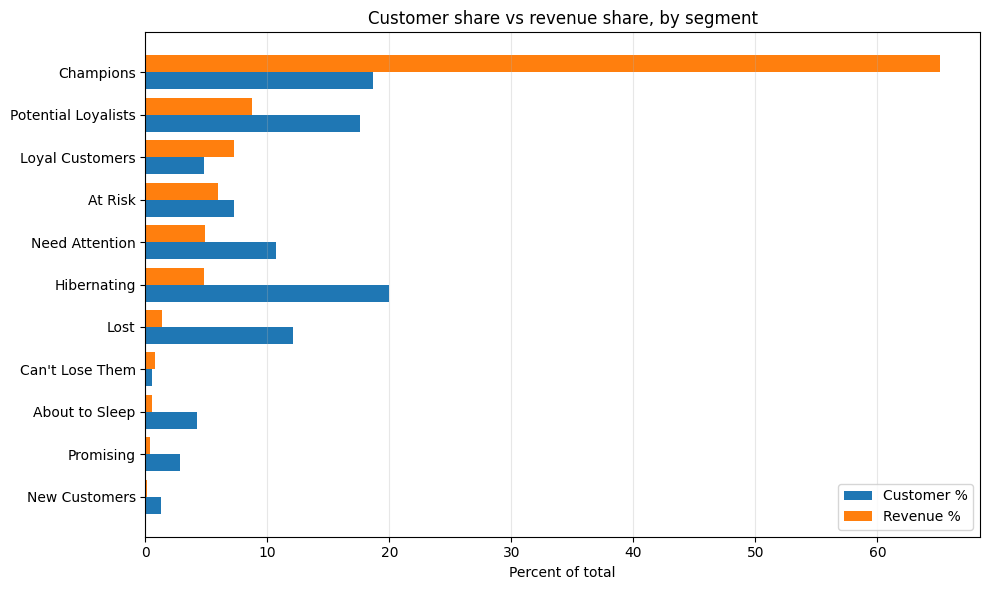

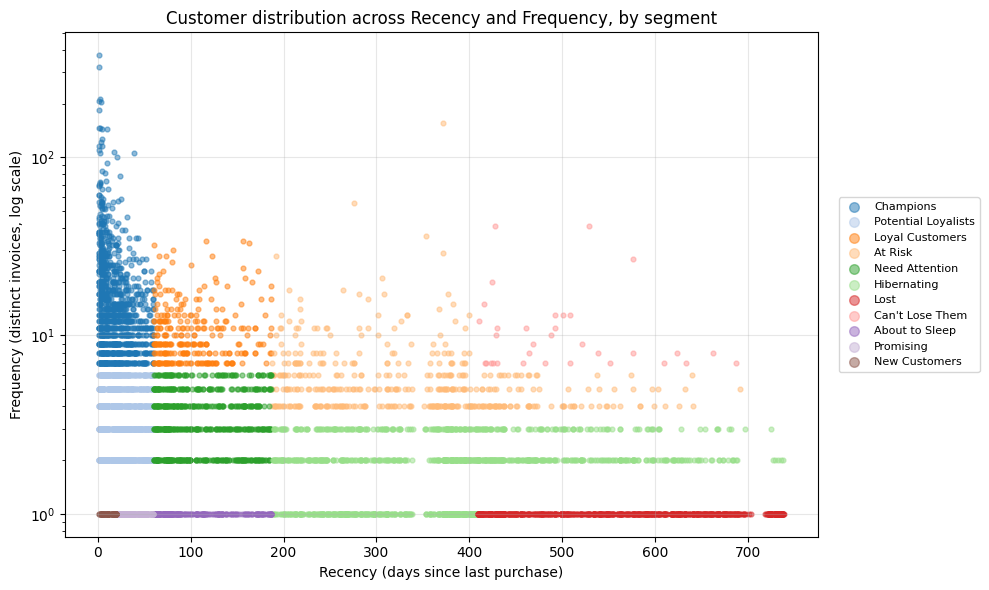

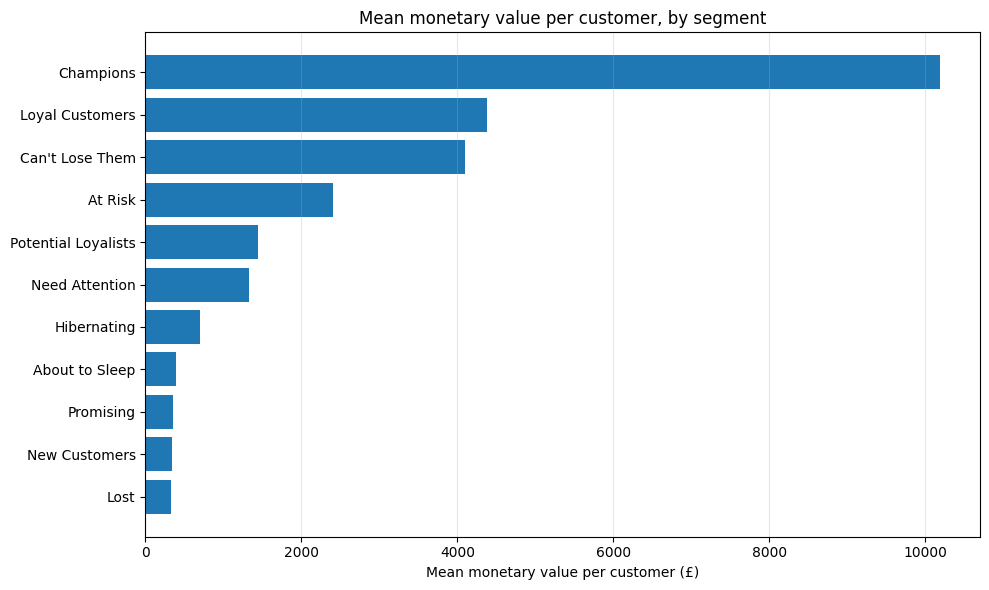

In [7]:
# Section 7 — Visualisations

# Order segments by revenue contribution descending (matches Section 6 table).
segment_order = segment_profile.index.tolist()

# Chart 1 — Customer share vs revenue share by segment.
figure_share, axes_share = plt.subplots(figsize=(10, 6))

bar_positions = range(len(segment_order))
bar_height = 0.4
customer_percentages = segment_profile.loc[segment_order, "customer_percent"].values
revenue_percentages = segment_profile.loc[segment_order, "revenue_percent"].values

axes_share.barh(
    [position + bar_height / 2 for position in bar_positions],
    customer_percentages,
    height=bar_height,
    label="Customer %",
)
axes_share.barh(
    [position - bar_height / 2 for position in bar_positions],
    revenue_percentages,
    height=bar_height,
    label="Revenue %",
)

axes_share.set_yticks(list(bar_positions))
axes_share.set_yticklabels(segment_order)
axes_share.invert_yaxis()  # Top of chart = highest revenue, matching table order.
axes_share.set_xlabel("Percent of total")
axes_share.set_title("Customer share vs revenue share, by segment")
axes_share.legend(loc="lower right")
axes_share.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Chart 2 — Recency vs Frequency scatter, coloured by segment.
# Explicit qualitative colourmap because matplotlib's default cycle has only
# 10 distinct colours, and 11 segments need 11.
figure_scatter, axes_scatter = plt.subplots(figsize=(10, 6))

segment_colours = plt.get_cmap("tab20").colors[:len(segment_order)]
for segment_name, segment_colour in zip(segment_order, segment_colours):
    segment_mask = rfm["Segment"] == segment_name
    axes_scatter.scatter(
        rfm.loc[segment_mask, "Recency"],
        rfm.loc[segment_mask, "Frequency"],
        s=12,
        alpha=0.5,
        color=segment_colour,
        label=segment_name,
    )

axes_scatter.set_yscale("log")
axes_scatter.set_xlabel("Recency (days since last purchase)")
axes_scatter.set_ylabel("Frequency (distinct invoices, log scale)")
axes_scatter.set_title("Customer distribution across Recency and Frequency, by segment")
axes_scatter.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    markerscale=2,
)
axes_scatter.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Chart 3 — Mean monetary value per segment.
mean_monetary_by_segment = (
    segment_profile["mean_monetary"]
    .sort_values(ascending=False)
)

figure_monetary, axes_monetary = plt.subplots(figsize=(10, 6))
axes_monetary.barh(
    mean_monetary_by_segment.index,
    mean_monetary_by_segment.values,
)
axes_monetary.invert_yaxis()  # Highest spender at the top.
axes_monetary.set_xlabel("Mean monetary value per customer (£)")
axes_monetary.set_title("Mean monetary value per customer, by segment")
axes_monetary.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Section 8 — Persist outputs

# Resolve the output path. project_root is in scope from Section 1.
output_path = project_root / "data" / "processed" / "rfm_segments.parquet"

# Confirm the target directory exists.
assert output_path.parent.is_dir(), (
    f"Output directory does not exist: {output_path.parent}"
)

# Define the final column order for the persisted output.
output_columns = [
    "Customer ID",
    "Recency", "Frequency", "Monetary",
    "R_Score", "F_Score", "M_Score", "RFM_Score",
    "Segment",
]

rfm_output = rfm[output_columns].copy()

# Write to parquet.
rfm_output.to_parquet(output_path, index=False)

print(f"Wrote: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")
print()

# Read back and validate the round-trip.
rfm_reloaded = pd.read_parquet(output_path)

# Validate shape and columns first for clear failure messages.
assert rfm_reloaded.shape == rfm_output.shape, (
    f"Round-trip shape mismatch: wrote {rfm_output.shape}, "
    f"read {rfm_reloaded.shape}."
)
assert list(rfm_reloaded.columns) == output_columns, (
    f"Round-trip column mismatch: {list(rfm_reloaded.columns)}"
)

# Strict round-trip equality on numeric columns.
# String columns are checked separately because pandas 3.0 / pyarrow round-trip
# can flip the NA-sentinel flavour of StringDtype (NA vs NaN) without changing
# any actual values; that difference is benign and not worth a strict failure.
numeric_columns = [
    "Customer ID",
    "Recency", "Frequency", "Monetary",
    "R_Score", "F_Score", "M_Score",
]
string_columns = ["RFM_Score", "Segment"]

pd.testing.assert_frame_equal(
    rfm_reloaded[numeric_columns],
    rfm_output[numeric_columns],
    check_dtype=True,
    check_exact=True,
)
pd.testing.assert_frame_equal(
    rfm_reloaded[string_columns],
    rfm_output[string_columns],
    check_dtype=False,
    check_exact=True,
)

# Confirm string columns are still string-typed after read-back, even if the
# specific StringDtype flavour differs from what we wrote.
for string_column in string_columns:
    assert pd.api.types.is_string_dtype(rfm_reloaded[string_column]), (
        f"{string_column} did not round-trip as string-dtype."
    )

# Report the persisted dataset summary.
print(f"Read-back rows: {rfm_reloaded.shape[0]:,}")
print(f"Read-back columns: {rfm_reloaded.shape[1]}")

print()
print("Read-back dtypes:")
print(rfm_reloaded.dtypes)

print()
print("Read-back sample:")
print(rfm_reloaded.head())

Wrote: C:\Users\Lenovo\Desktop\projects\retail-analytics\data\processed\rfm_segments.parquet
File size: 106.6 KB

Read-back rows: 5,852
Read-back columns: 9

Read-back dtypes:
Customer ID      Int64
Recency          int64
Frequency        int64
Monetary       float64
R_Score           int8
F_Score           int8
M_Score           int8
RFM_Score          str
Segment            str
dtype: object

Read-back sample:
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0        12346      326          3  77352.96        2        2        5   
1        12347        2          8   4921.53        5        4        5   
2        12348       75          5   1658.40        3        3        4   
3        12349       19          3   3678.69        5        2        5   
4        12350      310          1    294.40        2        1        2   

  RFM_Score              Segment  
0       225          Hibernating  
1       545            Champions  
2       334       Need Atten

## Findings summary

The RFM segmentation assigns 5,852 customers to 11 segment labels using recency quintiles, frequency cutoffs derived from the percentile distribution, and monetary quintiles. Key findings from this stage:

- **Champions hold 18.6% of customers and 65.2% of revenue** (Section 6 segment profile). The mean Champion has 19.2 distinct invoices and £10,194 in total spend — roughly 3.5× the dataset-wide mean of £2,917 (Section 3a).

- **The top three segments by revenue contribution drive 81.1% of total revenue.** Champions (65.2%), Potential Loyalists (8.7%), and Loyal Customers (7.3%) together account for the bulk of business value, while representing approximately 41% of customers (Section 6).

- **Frequency = 1 holds 27.65% of customers** (Section 3b), preventing standard five-bin quintile scoring on this dimension. Frequency was scored using fixed cutoffs derived from the percentile distribution: F = 1 → score 1, F ∈ [2, 3] → 2, F ∈ [4, 6] → 3, F ∈ [7, 12] → 4, F ≥ 13 → 5 (Section 4). Recency and Monetary scored cleanly into 5 quintiles each.

- **Revenue is heavily concentrated.** The top 1% of customers (59 customers) hold 32.1% of revenue; the top 20% hold 77.2% (Section 3c). Total dataset revenue is £17,068,582.72 across the two-year window from 2009-12-01 to 2011-12-09 (Section 1).

- **The lapsed-customer segments differ in size and value.** Hibernating is the largest segment by headcount (20.0%, 1,170 customers) but contributes only 4.8% of revenue. Lost holds 12.1% of customers and 1.4% of revenue. At Risk holds 7.2% of customers and 6.0% of revenue, with mean Frequency of 6.45, indicating customers with meaningful purchase history but low recent activity (Section 6).

- **Can't Lose Them is small but high-spending per customer.** This segment contains 33 customers (0.6% of the base), with mean Monetary of £4,096 — the fourth-highest mean spend across all segments — but contributes only 0.8% of total revenue (Section 6). The segment label reflects per-customer value, not aggregate financial weight.